# Move-triggered rebalance -- both legs resize together, on a price move, not a calendar

Synthesis of everything found today:

- **Calendar-only rebalancing** (`mstx_style_hedge_sandbox.ipynb`, 90-day rolls) fails
  because a fast leg (e.g. the Nov-Dec 2024 rally) blows through fixed coverage between
  rolls -- confirmed: hr=1.0 still gave -52% CAGR on testB, -138% MaxDD on the continuous
  run.
- **Unconstrained daily rebalancing** (the from-scratch rebuild's coverage-band, and
  `grid_search.py`'s 3-day-roll "winner") fails because sizing to a growing notional with
  no capital cap creates a leverage spiral, or the transaction costs alone kill it (that
  3-day-roll config lost money even on train/testA).
- **A fixed short-share-count held forever** (every version tried today, including
  `cba_backtest.py`'s `2.0 - cum_tsll` convention) lets short exposure grow unboundedly
  relative to equity in a rally -- confirmed to be the actual mechanism eating returns,
  not a lack of volatility decay (decay was real and large in every window checked, the
  hedge just couldn't survive the path to realize it).

**This notebook's design**: both the short leg AND the hedge resize together, triggered
by how far TSLL has actually moved since the last rebalance -- not a fixed calendar, not
every day regardless. Specifically:

- Reuses `cba_backtest.py`'s real transaction-cost model (vol/liquidity-scaled, base
  1%/3% per leg) and the real TSLL borrow-rate series -- nothing re-derived.
- Reuses the cost-benefit rule: price both TSLA and TSLL calls each rebalance, buy
  whichever's cheaper.
- **New**: the short leg is rescaled at every rebalance to track current equity
  (`target_short_notional = max(equity, 0)`) -- capital-constrained, can't run away
  unboundedly like every prior fixed-share design.
- **New**: rebalance triggers on EITHER a DTE floor (contract expiring) OR TSLL having
  moved >= `move_threshold` since the last rebalance -- whichever comes first. A grid over
  `move_threshold` (including an effectively-disabled case, for a same-cost-model,
  calendar-only comparison point) shows whether the move trigger actually helps.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from options_selection import select_contract, bs_delta
from metrics import summarize
from grid_search import load_data

R_RF = 0.05
%matplotlib inline
print("Imports OK")

Imports OK


## Load data (same loader as the CBA ensemble / grid search)

In [2]:
data = load_data()
(returns, tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
 tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma, borrow_df) = data

dates = returns.index
print(f"Full window: {len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

Full window: 960 trading days, 2022-08-12 -> 2026-06-10


## Windows -- same dates used for every held-out check today

In [3]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END   = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")   # decline
TEST_A_END   = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")   # rally
TEST_B_END   = pd.Timestamp("2025-12-16")

WINDOWS = {
    "train": dates[(dates >= TRAIN_START) & (dates <= TRAIN_END)],
    "testA": dates[(dates >= TEST_A_START) & (dates <= TEST_A_END)],
    "testB": dates[(dates >= TEST_B_START) & (dates <= TEST_B_END)],
    "continuous_out_of_train": dates[dates > TRAIN_END],
}
for name, w in WINDOWS.items():
    print(f"{name:>24s}: {len(w):4d} days, {w.min().date()} -> {w.max().date()}")

                   train:   80 days, 2022-09-09 -> 2023-01-03
                   testA:   76 days, 2024-12-17 -> 2025-04-08
                   testB:  175 days, 2025-04-08 -> 2025-12-16
 continuous_out_of_train:  861 days, 2023-01-04 -> 2026-06-10


## `simulate_move_triggered`

In [4]:
def simulate_move_triggered(sim_dates, moneyness_bucket, target_dte, roll_dte, max_dte,
                             move_threshold, hedge_ratio, tsll_lever,
                             tsla_cost_pct, tsll_cost_pct, tsll_borrow_rate):
    """Short TSLL + cost-benefit (TSLA vs TSLL) call, both legs resized together whenever
    TSLL has moved >= move_threshold since the last rebalance OR the held contract's DTE
    drops below roll_dte -- whichever comes first. Short leg is rescaled to track current
    equity each time (capital-constrained), not held at a fixed share count forever.

    `tsll_lever` scales the TSLA leg's target dollar-delta (a TSLA call only delivers 1x
    delta per dollar of TSLA move, but TSLL moves ~tsll_lever x TSLA -- so a TSLA-call hedge
    needs tsll_lever x the dollar-delta a TSLL-call hedge needs for the same coverage).
    This matches cba_backtest.py's `leverage_factor`/`TSLL_LEVER` convention exactly --
    an earlier version of this function used the same target for both legs, silently
    under-hedging by ~2x whenever TSLA was the cheaper pick. Fixed here."""
    equity_notional = 1.0
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = equity_notional / S_incep
    last_rebalance_price = S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    S_prev = S_incep
    stats = {"dte_rolls": 0, "move_rolls": 0, "fills_tsla": 0, "fills_tsll": 0, "misses": 0,
             "exit_misses": 0, "transaction_costs_paid": 0.0, "borrow_paid": 0.0}

    equity = pd.Series(index=sim_dates, dtype=float)

    sigma_baseline = {"tsla": float(tsla_sigma.median()) if tsla_sigma.median() > 0 else 0.5,
                       "tsll": float(tsll_sigma.median()) if tsll_sigma.median() > 0 else 0.5}
    volume_baseline = {"tsla": float(tsla_calls["px_volume"].median()),
                        "tsll": float(tsll_calls["px_volume"].median())}

    def cost_of(underlying, premium_value, date, volume):
        rate = tsla_cost_pct if underlying == "tsla" else tsll_cost_pct
        sigma_series = tsla_sigma if underlying == "tsla" else tsll_sigma
        sig_now = float(sigma_series.loc[date]) if date in sigma_series.index else sigma_baseline[underlying]
        vol_mult = np.clip(sig_now / sigma_baseline[underlying], 0.5, 2.5)
        liq_mult = np.clip(volume_baseline[underlying] / max(volume, 1.0), 0.5, 3.0)
        return premium_value * rate * vol_mult * liq_mult

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_lookup if pos["underlying"] == "tsla" else tsll_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        return float(px) if px is not None and pd.notna(px) else pos["price"]

    def can_exit(pos, date):
        if date > pos["expiry"]:
            return True
        vol_lkp = tsla_vol_lookup if pos["underlying"] == "tsla" else tsll_vol_lookup
        vol = vol_lkp.get((pos["raw_id"], date))
        return vol is not None and pd.notna(vol) and vol > 0

    def open_position(d, target_dollar_delta):
        sig_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
        sig_b = float(tsll_sigma.loc[d]) if d in tsll_sigma.index else 0.5
        row_a = select_contract(tsla_calls, tsla_spot, d, moneyness_bucket, target_dte, max_dte)
        row_b = select_contract(tsll_calls, tsll_spot, d, moneyness_bucket, target_dte, max_dte)

        def cost_n_entry(row, spot_val, sigma_val, leverage):
            if row is None:
                return float("inf"), 0.0, 0.0
            entry = float(row["px_last"])
            T = max((row["expiry"] - d).days / 365.25, 1 / 365)
            delta = bs_delta(spot_val, float(row["strike"]), T, R_RF, sigma_val)
            n = leverage * target_dollar_delta / (max(delta, 0.01) * 100 * spot_val)
            return n * 100 * entry, n, entry

        # TSLA leg needs tsll_lever x the dollar-delta target (a TSLA call only delivers 1x
        # delta per dollar of TSLA move); TSLL leg is 1:1 since it's on the LETF itself.
        cost_a, n_a, entry_a = cost_n_entry(row_a, float(tsla_spot.loc[d]), sig_a, tsll_lever)
        cost_b, n_b, entry_b = cost_n_entry(row_b, float(tsll_spot.loc[d]), sig_b, 1.0)

        chosen = None
        if row_a is not None and (row_b is None or cost_a <= cost_b):
            chosen, row, n, entry, ul = "tsla", row_a, n_a, entry_a, "tsla"
        elif row_b is not None:
            chosen, row, n, entry, ul = "tsll", row_b, n_b, entry_b, "tsll"
        if chosen is None:
            return None, 0.0

        entry_volume = float(row["px_volume"]) if pd.notna(row.get("px_volume")) else volume_baseline[ul]
        open_cost = cost_of(ul, n * 100 * entry, d, entry_volume)
        new_pos = {"underlying": ul, "raw_id": row["raw_id"], "strike": float(row["strike"]),
                   "expiry": row["expiry"], "n": n, "price": entry, "entry_volume": entry_volume}
        return new_pos, open_cost

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        if tsll_borrow_rate is not None:
            current_short_notional = n_shares * S_today
            daily_cost = float(tsll_borrow_rate.loc[d]) / 252 * current_short_notional
            short_pnl -= daily_cost
            stats["borrow_paid"] += daily_cost

        held_dte = (position["expiry"] - d).days if position is not None else -1
        dte_forced = position is None or held_dte < roll_dte
        move_pct = abs(S_today / last_rebalance_price - 1) if last_rebalance_price > 0 else 0.0
        move_forced = move_pct >= move_threshold
        exitable = position is None or can_exit(position, d)

        if (dte_forced or move_forced) and exitable:
            if position is not None:
                close_cost = cost_of(position["underlying"], position["n"] * 100 * position["price"],
                                     d, position["entry_volume"])
                option_pnl -= close_cost
                stats["transaction_costs_paid"] += close_cost
                if dte_forced:
                    stats["dte_rolls"] += 1
                else:
                    stats["move_rolls"] += 1
                position = None

            equity_now = equity_notional + short_pnl + option_pnl
            target_short_notional = max(equity_now, 0.0)
            if S_today > 0:
                n_shares = target_short_notional / S_today
            last_rebalance_price = S_today

            target_dollar_delta = hedge_ratio * target_short_notional
            new_pos, open_cost = open_position(d, target_dollar_delta)
            if new_pos is not None:
                option_pnl -= open_cost
                stats["transaction_costs_paid"] += open_cost
                position = new_pos
                stats[f"fills_{new_pos['underlying']}"] += 1
            else:
                stats["misses"] += 1
        elif (dte_forced or move_forced) and not exitable:
            stats["exit_misses"] += 1

        equity.loc[d] = equity_notional + short_pnl + option_pnl

    return equity, stats

## Grid over move_threshold -- base costs, 10% OTM, target_dte=90, roll_dte=14, hedge_ratio=1.0

In [5]:
MONEYNESS_BUCKET = "10% OTM"
TARGET_DTE = 90
ROLL_DTE = 14
MAX_DTE = 110
HEDGE_RATIO = 1.0
TSLL_LEVER = 2.0   # stated convention, matches cba_backtest.py -- confirmed close to the
                   # realized daily-tracking beta in testA/testB (median 1.99) this session
TSLA_COST_PCT = 0.010
TSLL_COST_PCT = 0.030
tsll_borrow_rate = borrow_df["TSLL"]

# 999.0 = effectively disabled -- pure calendar-only comparison point, same cost model
MOVE_THRESHOLDS = [0.15, 0.25, 0.35, 999.0]

curves = {}
rows = []
for win_name, win_dates in WINDOWS.items():
    curves[win_name] = {}
    for thr in MOVE_THRESHOLDS:
        label = f"move>={thr:.0%}" if thr < 1.0 else "calendar-only (no move trigger)"
        eq, stats = simulate_move_triggered(
            win_dates, MONEYNESS_BUCKET, TARGET_DTE, ROLL_DTE, MAX_DTE, thr, HEDGE_RATIO, TSLL_LEVER,
            TSLA_COST_PCT, TSLL_COST_PCT, tsll_borrow_rate)
        curves[win_name][label] = eq
        row = summarize(eq, eq.pct_change().dropna(), label)
        row["window"] = win_name
        row["dte_rolls"] = stats["dte_rolls"]
        row["move_rolls"] = stats["move_rolls"]
        row["fills_tsla"] = stats["fills_tsla"]
        row["fills_tsll"] = stats["fills_tsll"]
        row["misses"] = stats["misses"]
        row["exit_misses"] = stats["exit_misses"]
        row["transaction_costs_paid"] = round(stats["transaction_costs_paid"], 4)
        row["borrow_paid"] = round(stats["borrow_paid"], 4)
        rows.append(row)

results_df = pd.DataFrame(rows)[["Strategy", "window", "CAGR", "Ann. Vol", "Sharpe", "Max DD", "Calmar",
                                  "dte_rolls", "move_rolls", "fills_tsla", "fills_tsll", "misses", "exit_misses",
                                  "transaction_costs_paid", "borrow_paid"]]
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
results_df

,Strategy,window,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,dte_rolls,move_rolls,fills_tsla,fills_tsll,misses,exit_misses,transaction_costs_paid,borrow_paid
0,move>=15%,train,0.252623,0.714647,0.686283,-0.236751,1.067041,0,13,6,8,2,0,0.2306,0.0198
1,move>=25%,train,-0.010102,0.538844,0.265222,-0.190195,-0.053115,1,3,3,2,2,3,0.0532,0.0182
2,move>=35%,train,0.178779,0.822492,0.627104,-0.285070,0.627140,1,2,2,2,0,12,0.0436,0.0175
3,calendar-only (no move trigger),train,1.511464,0.419628,2.460265,-0.091564,16.507244,1,0,2,0,0,0,0.0065,0.0143
4,move>=15%,testA,0.202499,0.478694,0.646652,-0.224329,0.902689,0,13,4,10,0,0,0.1478,0.0139
5,move>=25%,testA,0.689425,0.498434,1.344320,-0.233102,2.957615,0,7,2,6,0,0,0.1155,0.0139
6,move>=35%,testA,3.154377,0.634656,2.631432,-0.189120,16.679240,1,4,3,3,0,0,0.0566,0.0160
7,calendar-only (no move trigger),testA,1.501237,0.527094,2.067166,-0.148316,10.121850,1,0,2,0,0,0,0.0071,0.0128
8,move>=15%,testB,-0.628490,0.286564,-3.282389,-0.536424,-1.171627,0,19,5,15,0,0,0.2029,0.0126
9,move>=25%,testB,-0.536336,0.328295,-2.153896,-0.469443,-1.142494,1,11,5,8,0,0,0.1450,0.0131


## Equity curves, per window

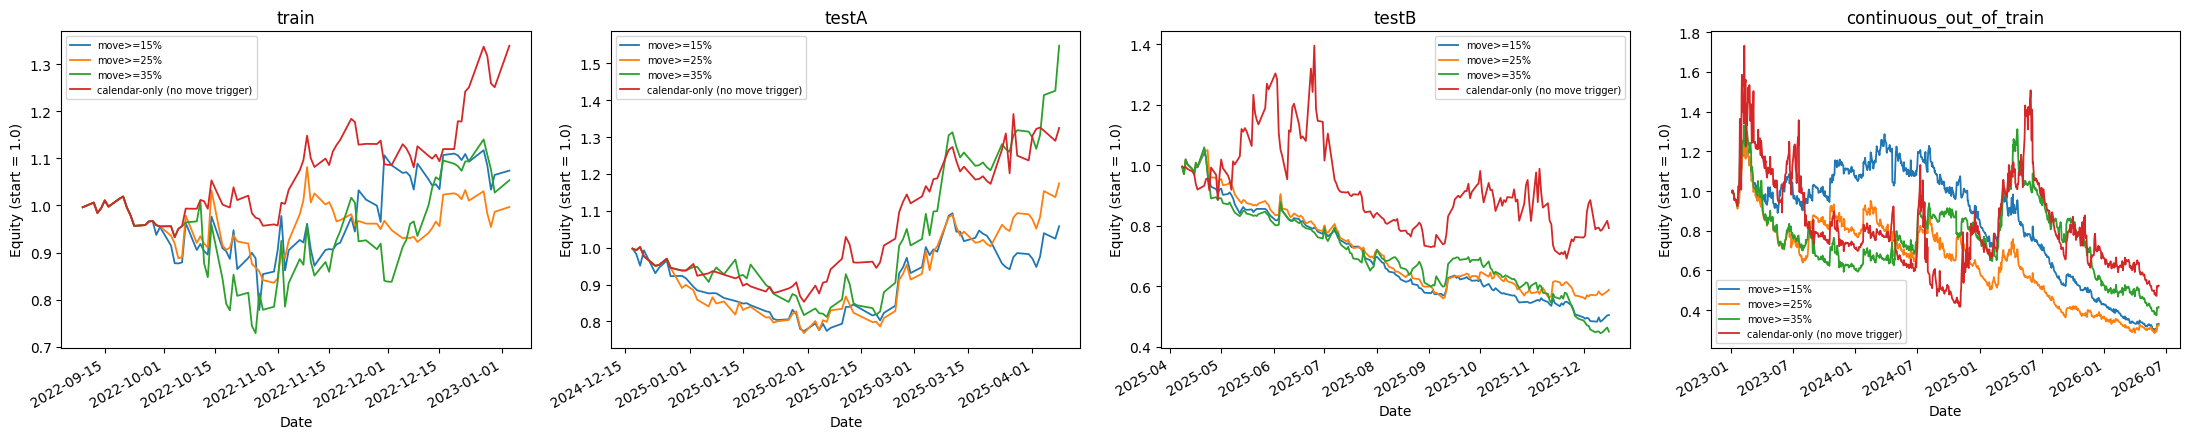

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for ax, win_name in zip(axes, WINDOWS.keys()):
    for label, eq in curves[win_name].items():
        eq.plot(ax=ax, label=label, linewidth=1.3)
    ax.set_title(win_name)
    ax.set_ylabel("Equity (start = 1.0)")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## Sanity checks

In [7]:
for win_name, per_label in curves.items():
    for label, eq in per_label.items():
        assert eq.isna().sum() == 0, f"{win_name} / {label}: equity has NaNs"
        assert eq.min() > -5.0, f"{win_name} / {label}: equity fell to an implausible level ({eq.min():.2f})"

print("Sanity checks passed.")
print("\nFull comparison:")
print(results_df.to_string(index=False))

Sanity checks passed.

Full comparison:
                       Strategy                  window      CAGR  Ann. Vol    Sharpe    Max DD    Calmar  dte_rolls  move_rolls  fills_tsla  fills_tsll  misses  exit_misses  transaction_costs_paid  borrow_paid
                      move>=15%                   train  0.252623  0.714647  0.686283 -0.236751  1.067041          0          13           6           8       2            0                  0.2306       0.0198
                      move>=25%                   train -0.010102  0.538844  0.265222 -0.190195 -0.053115          1           3           3           2       2            3                  0.0532       0.0182
                      move>=35%                   train  0.178779  0.822492  0.627104 -0.285070  0.627140          1           2           2           2       0           12                  0.0436       0.0175
calendar-only (no move trigger)                   train  1.511464  0.419628  2.460265 -0.091564 16.507244          1